In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better looking default style (optional but recommended)
plt.style.use('seaborn-v0_8')          # or 'ggplot', 'bmh', etc.
sns.set_theme(style="whitegrid")       # nice seaborn look

# ─── Sample datasets we will use ───
# 1. Simple time series
dates = pd.date_range('2025-01-01', periods=100, freq='D')
ts = pd.Series(np.random.randn(100).cumsum(), index=dates)

# 2. Classic random DataFrame
df = pd.DataFrame({
    'Sales':    np.random.randint(100, 800, 50),
    'Profit':   np.random.uniform(-20, 120, 50),
    'Category': np.random.choice(['A','B','C','D'], 50),
    'Region':   np.random.choice(['North','South','East','West'], 50),
    'Rating':   np.random.uniform(1, 5, 50)
}, index=pd.date_range('2025-01-01', periods=50))

df['Month'] = df.index.strftime('%b')

# 3. For histograms / distributions
tips = sns.load_dataset('tips')   # built-in seaborn dataset (very useful for teaching)

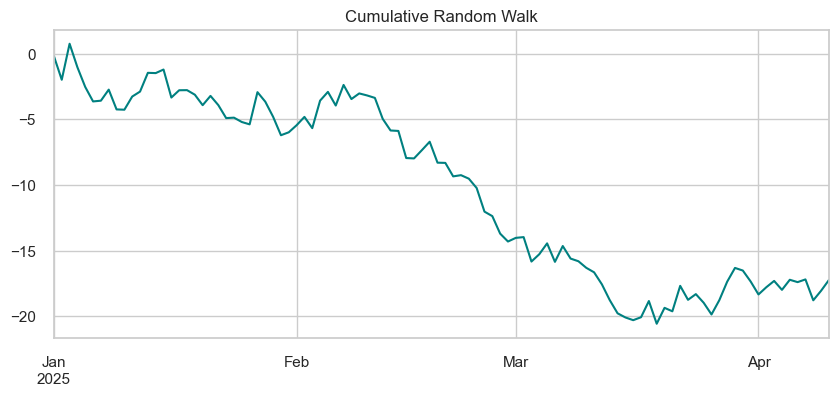

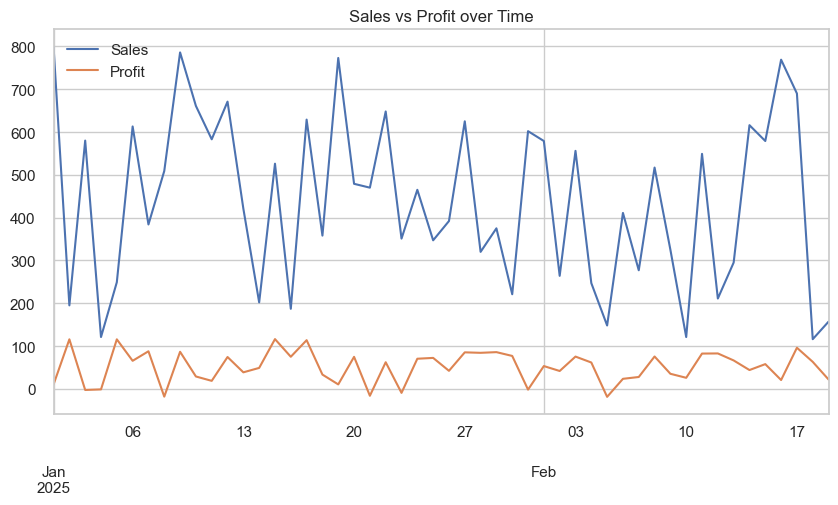

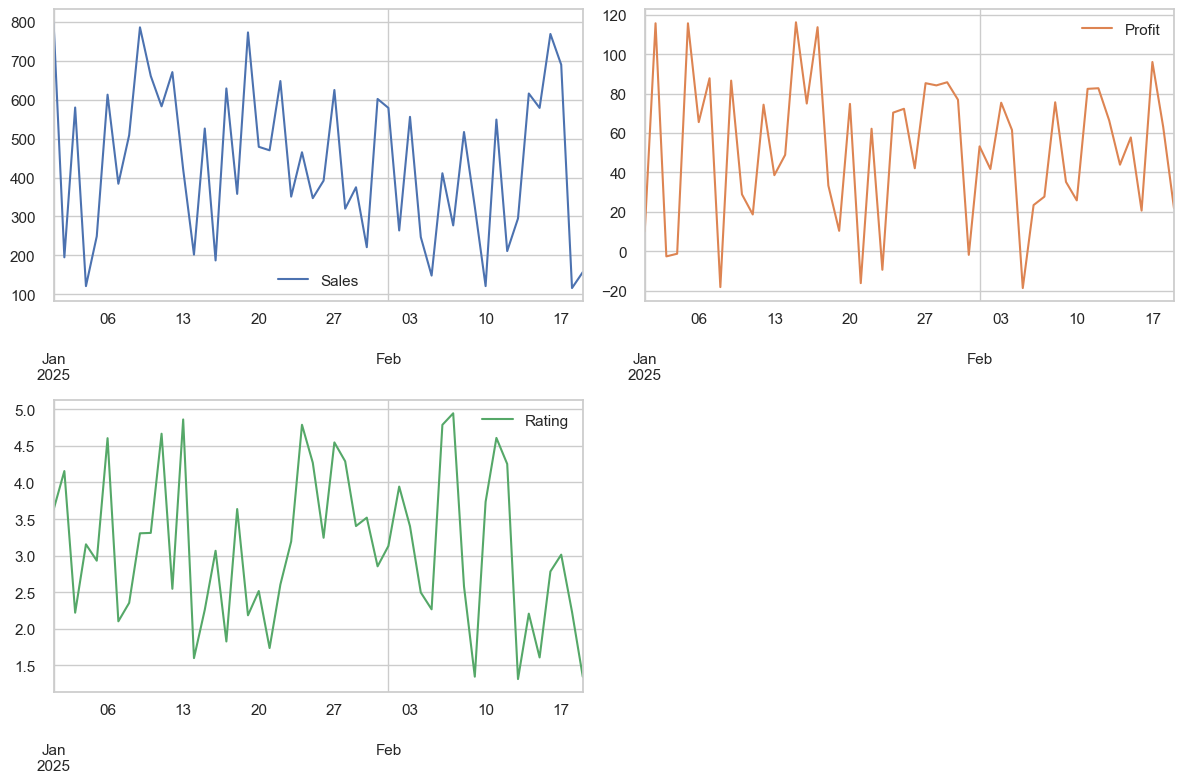

In [2]:
# Basic line from Series
ts.plot(figsize=(10,4), title="Cumulative Random Walk", color="teal")
plt.show()

# Multiple lines from DataFrame
df[['Sales','Profit']].plot(figsize=(10,5), title="Sales vs Profit over Time")
plt.show()

# With subplots (very useful!)
df.plot(subplots=True, layout=(2,2), figsize=(12,8), sharex=False)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create sample dataset
np.random.seed(42)
dates = pd.date_range('2023-01-01', periods=100, freq='D')
df = pd.DataFrame({
    'Date': dates,
    'Sales': np.random.randint(100, 500, 100),
    'Customers': np.random.randint(50, 200, 100),
    'Product_A': np.random.normal(300, 50, 100),
    'Product_B': np.random.normal(250, 60, 100),
    'Product_C': np.random.normal(200, 40, 100)
})
df.set_index('Date', inplace=True)

print(df.head())

            Sales  Customers   Product_A   Product_B   Product_C
Date                                                            
2023-01-01    202         64  289.283776  216.643306  146.307487
2023-01-02    448         94  265.540289  242.335910   65.436179
2023-01-03    370        114  336.391656  156.366576  244.941671
2023-01-04    206        138  269.046532  370.020885  285.728208
2023-01-05    171        120  317.807992  177.992096  186.296445


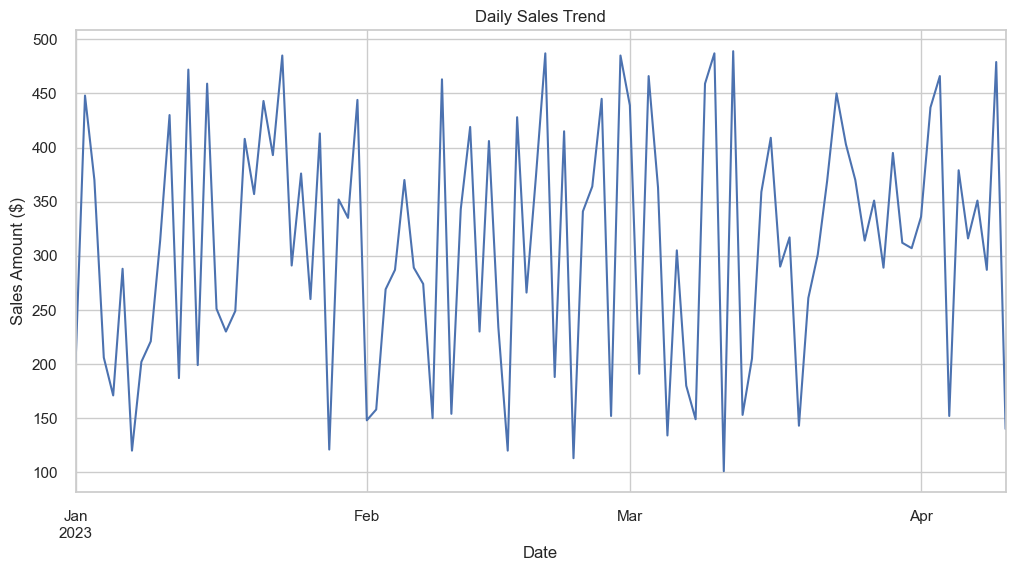

In [4]:
#Basic Line Plot
# Simple line plot
df['Sales'].plot(figsize=(12, 6), title='Daily Sales Trend')
plt.ylabel('Sales Amount ($)')
plt.xlabel('Date')
plt.show()

In [5]:
#Line Plots - Multiple Series
#Comparing Multiple Time Series

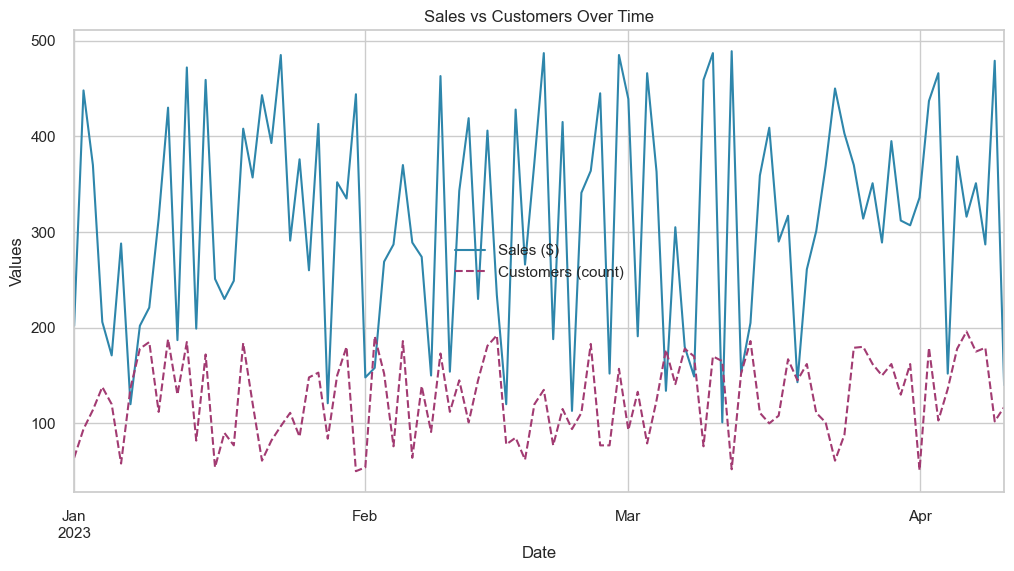

In [6]:
# Plot multiple columns
df[['Sales', 'Customers']].plot(
    figsize=(12, 6),
    title='Sales vs Customers Over Time',
    style=['-', '--'],
    color=['#2E86AB', '#A23B72']
)
plt.ylabel('Values')
plt.xlabel('Date')
plt.legend(['Sales ($)', 'Customers (count)'])
plt.show()

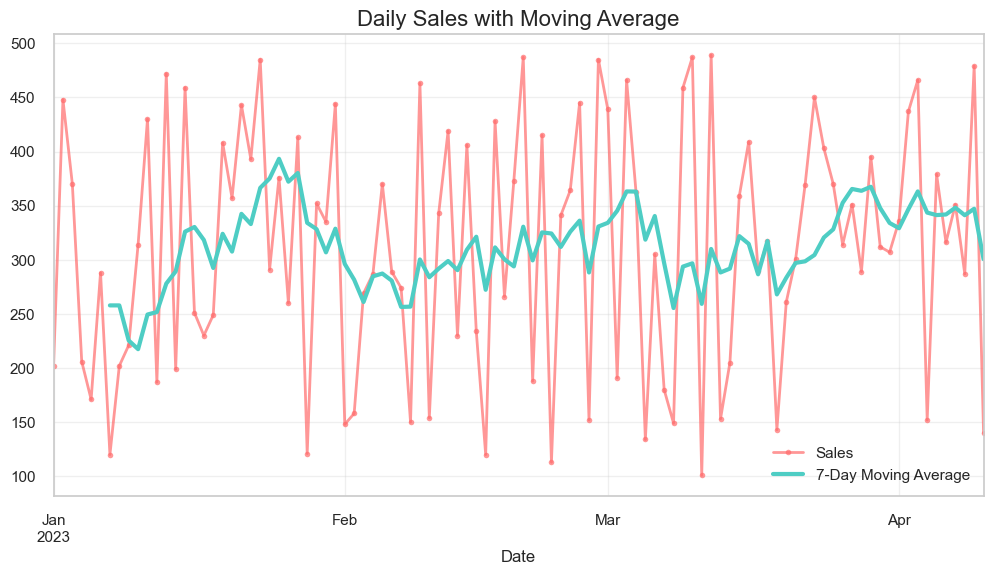

In [7]:
#Customizing Line Plots
# Advanced customization
ax = df['Sales'].plot(
    figsize=(12, 6),
    linewidth=2,
    marker='o',
    markersize=4,
    color='#FF6B6B',
    alpha=0.7
)

# Add rolling average
df['Sales'].rolling(window=7).mean().plot(
    ax=ax,
    color='#4ECDC4',
    linewidth=3,
    label='7-Day Moving Average'
)

plt.title('Daily Sales with Moving Average', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\Bhavanah\AppData\Local\Temp\ipykernel_11064\3109453942.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample('M').mean()


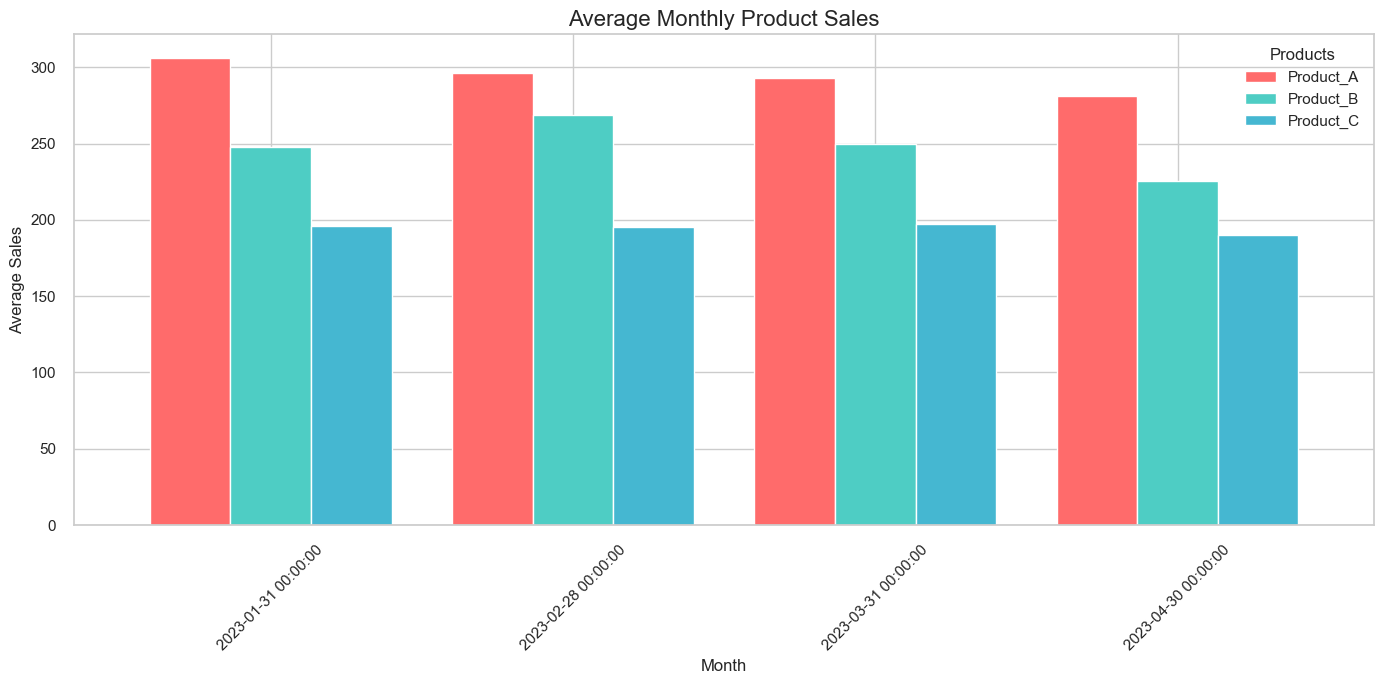

In [8]:
#Bar Plots - Categorical Comparisons
#Vertical Bar Plots

# Monthly aggregation
monthly_data = df.resample('M').mean()
monthly_data[['Product_A', 'Product_B', 'Product_C']].plot(
    kind='bar',
    figsize=(14, 7),
    width=0.8,
    color=['#FF6B6B', '#4ECDC4', '#45B7D1']
)

plt.title('Average Monthly Product Sales', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.legend(title='Products')
plt.tight_layout()
plt.show()

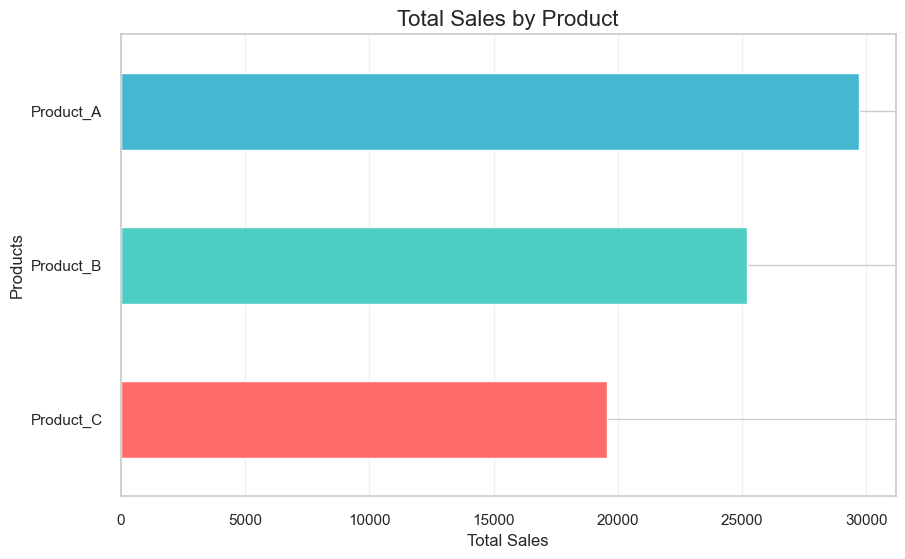

In [9]:
#Horizontal Bar Plots
# Horizontal bar plot for better label readability
top_products = df[['Product_A', 'Product_B', 'Product_C']].sum().sort_values()
top_products.plot(
    kind='barh',
    figsize=(10, 6),
    color=['#FF6B6B', '#4ECDC4', '#45B7D1']
)

plt.title('Total Sales by Product', fontsize=16)
plt.xlabel('Total Sales')
plt.ylabel('Products')
plt.grid(True, alpha=0.3, axis='x')
plt.show()

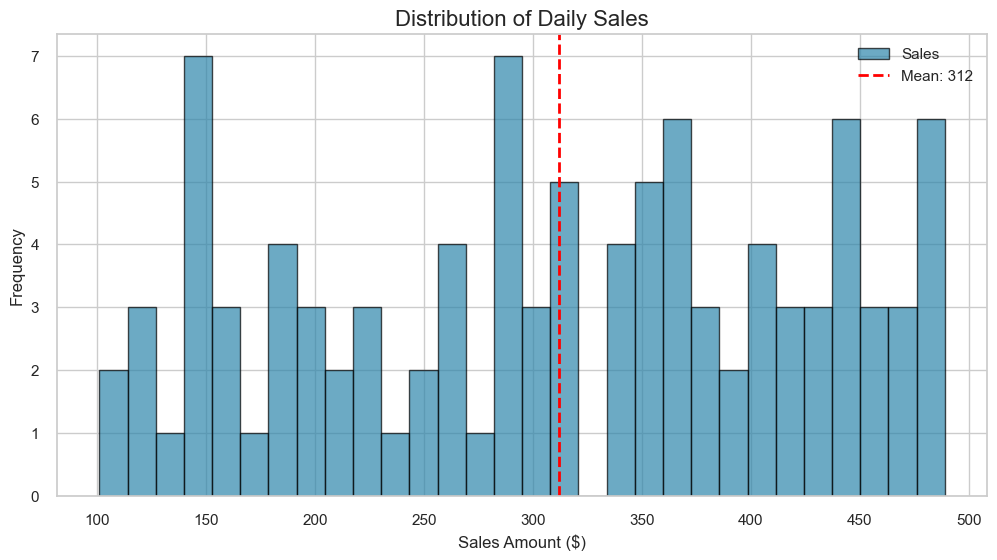

In [10]:
#Histograms - Distribution Analysis
#Understanding Data Distribution

# Single histogram
df['Sales'].plot(
    kind='hist',
    bins=30,
    figsize=(12, 6),
    edgecolor='black',
    alpha=0.7,
    color='#2E86AB'
)

plt.title('Distribution of Daily Sales', fontsize=16)
plt.xlabel('Sales Amount ($)')
plt.ylabel('Frequency')
plt.axvline(df['Sales'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Sales"].mean():.0f}')
plt.legend()
plt.show()

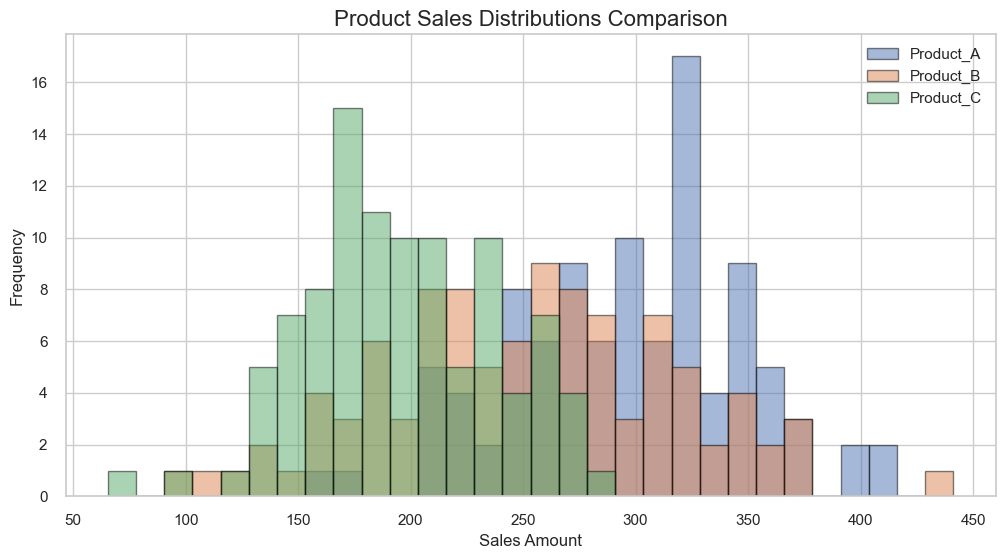

In [11]:
#Multiple Histograms
# Overlapping histograms
df[['Product_A', 'Product_B', 'Product_C']].plot(
    kind='hist',
    bins=30,
    alpha=0.5,
    figsize=(12, 6),
    edgecolor='black'
)

plt.title('Product Sales Distributions Comparison', fontsize=16)
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

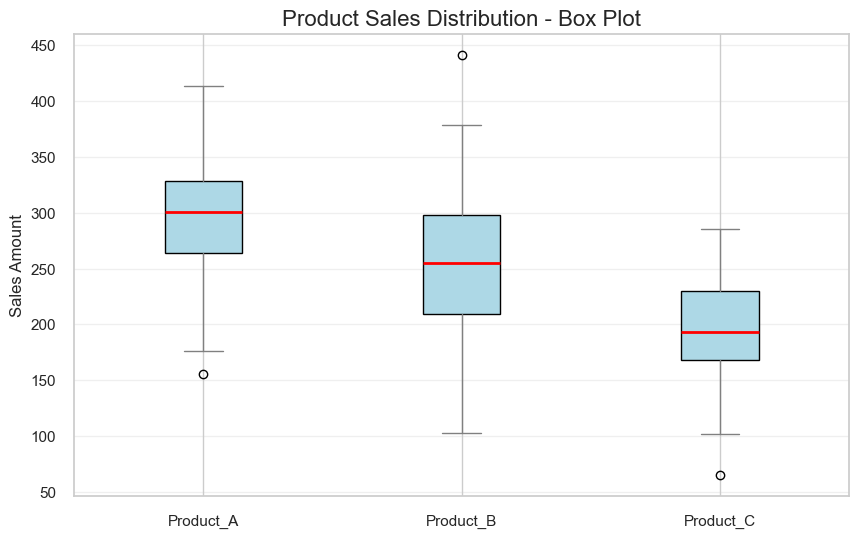

In [12]:
#Box Plots - Statistical Summary
#Understanding Data Spread and Outliers

# Box plot for multiple columns
df[['Product_A', 'Product_B', 'Product_C']].plot(
    kind='box',
    figsize=(10, 6),
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray'),
    medianprops=dict(color='red', linewidth=2)
)

plt.title('Product Sales Distribution - Box Plot', fontsize=16)
plt.ylabel('Sales Amount')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

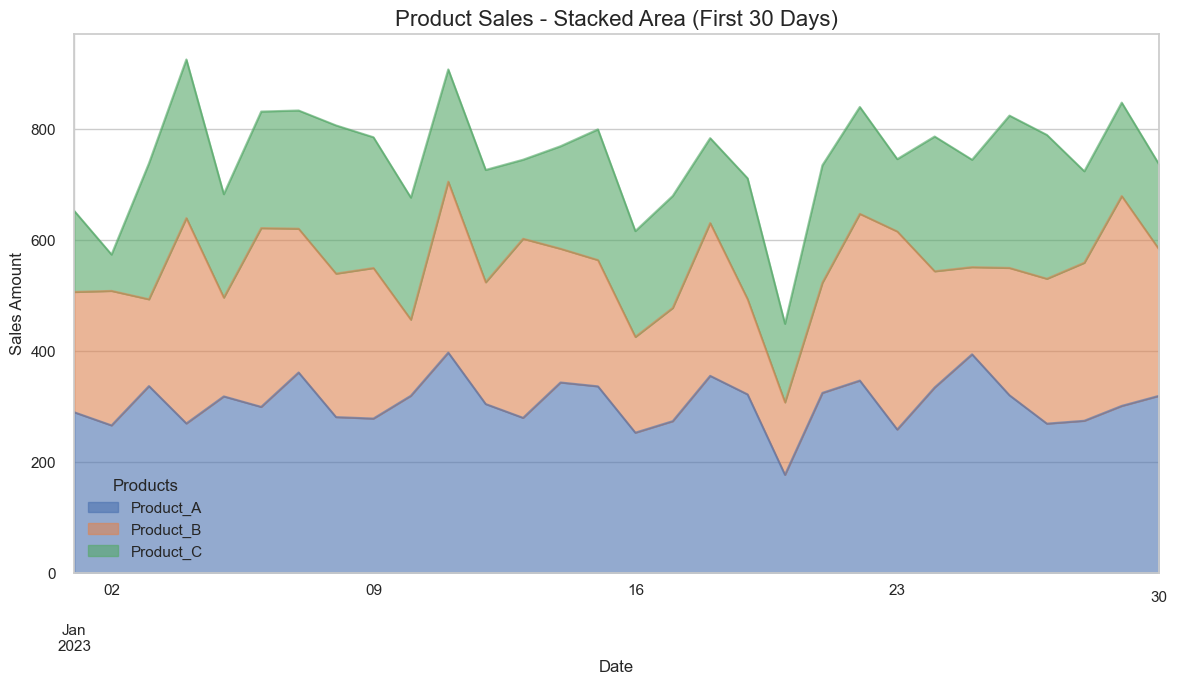

In [13]:
#Area Plots - Cumulative Trends
#Stacked and Unstacked Area Charts

# Stacked area plot
df[['Product_A', 'Product_B', 'Product_C']].head(30).plot(
    kind='area',
    figsize=(14, 7),
    alpha=0.6,
    stacked=True
)

plt.title('Product Sales - Stacked Area (First 30 Days)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.legend(title='Products')
plt.show()

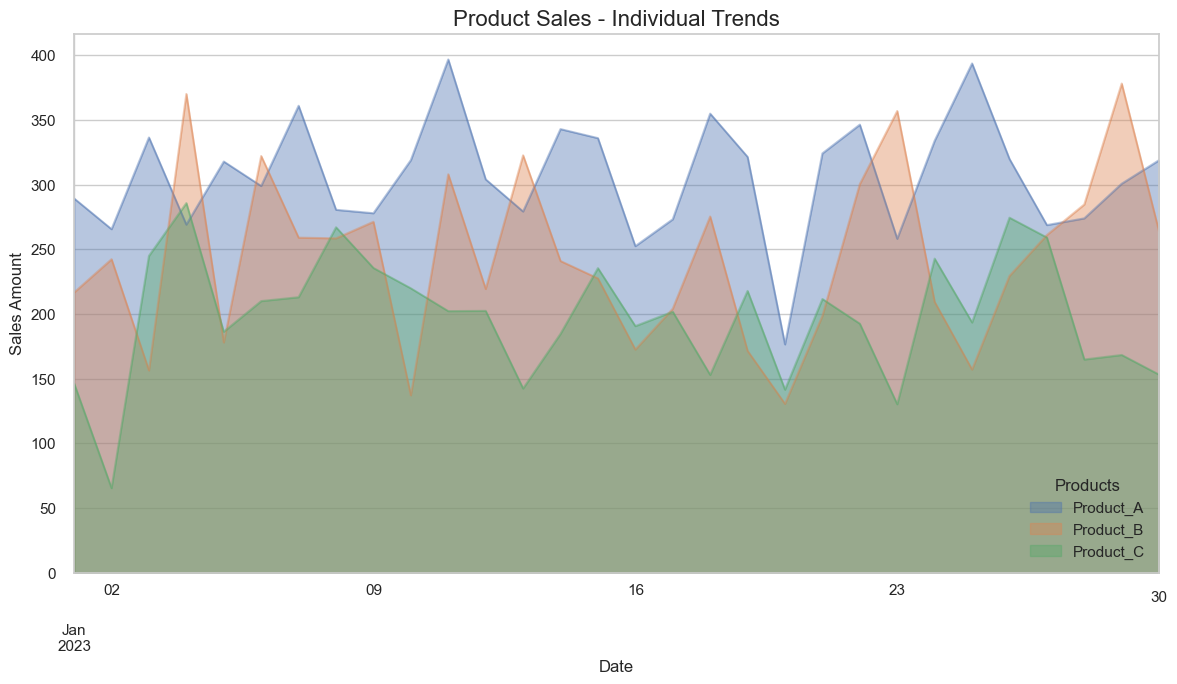

In [14]:
# Non-stacked area plot for individual trends
df[['Product_A', 'Product_B', 'Product_C']].head(30).plot(
    kind='area',
    figsize=(14, 7),
    alpha=0.4,
    stacked=False
)

plt.title('Product Sales - Individual Trends', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.legend(title='Products')
plt.show()

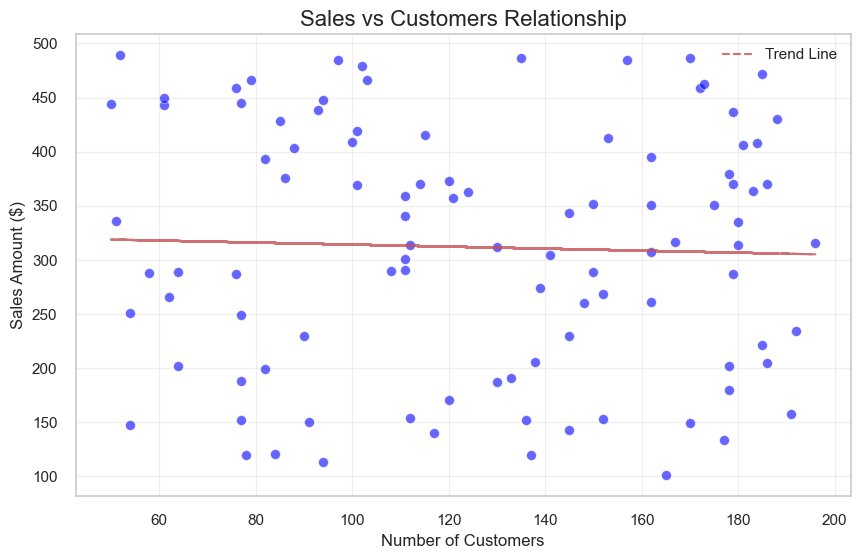

In [15]:
#Scatter Plots - Correlation Analysis
#Relationship Between Variables

# Basic scatter plot
df.plot(
    kind='scatter',
    x='Customers',
    y='Sales',
    figsize=(10, 6),
    s=50,  # marker size
    c='blue',
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5
)

plt.title('Sales vs Customers Relationship', fontsize=16)
plt.xlabel('Number of Customers')
plt.ylabel('Sales Amount ($)')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['Customers'], df['Sales'], 1)
p = np.poly1d(z)
plt.plot(df['Customers'], p(df['Customers']), "r--", alpha=0.8, label='Trend Line')
plt.legend()
plt.show()

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

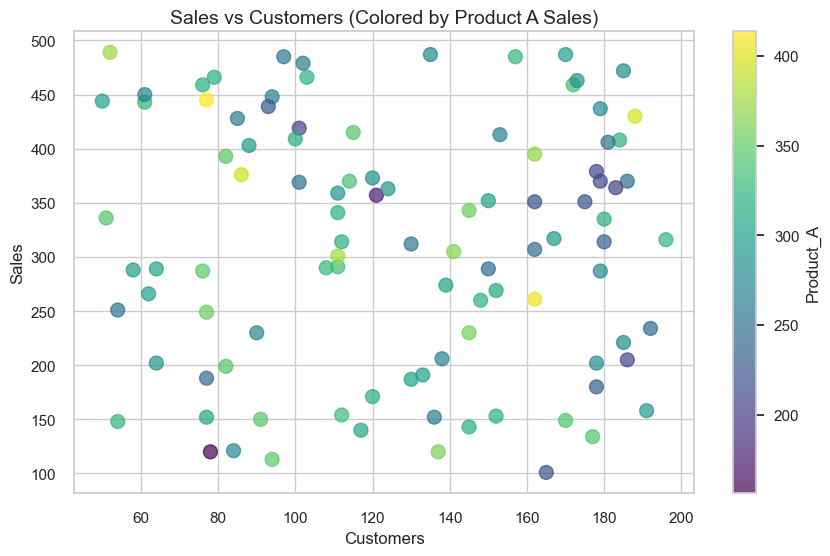

In [16]:
# Scatter plot with color mapping
scatter = df.plot(
    kind='scatter',
    x='Customers',
    y='Sales',
    c='Product_A',  # Color by Product_A sales
    colormap='viridis',
    figsize=(10, 6),
    s=100,
    alpha=0.7
)

plt.title('Sales vs Customers (Colored by Product A Sales)', fontsize=14)
plt.colorbar(label='Product A Sales')
plt.show()

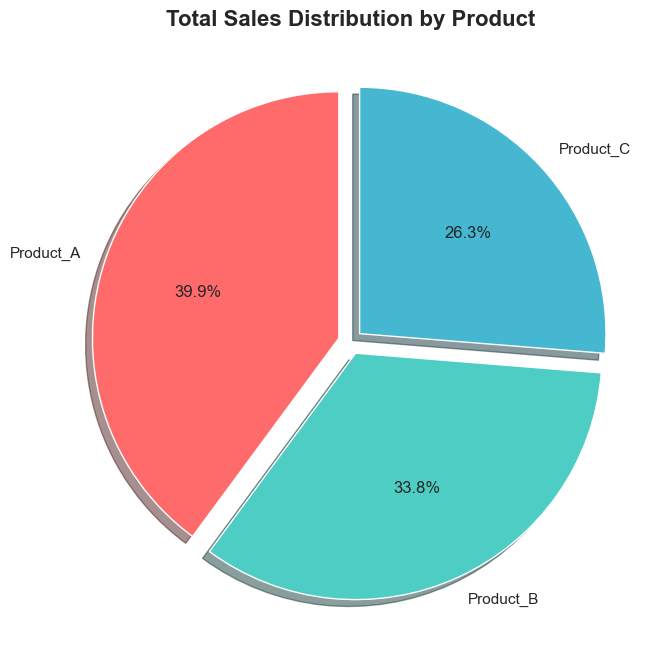

In [17]:
#Pie Charts - Proportion Analysis
#Showing Composition

# Create pie chart for total product sales
total_sales = df[['Product_A', 'Product_B', 'Product_C']].sum()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

total_sales.plot(
    kind='pie',
    figsize=(8, 8),
    autopct='%1.1f%%',
    colors=colors,
    explode=(0.05, 0.05, 0.05),  # Slight separation
    shadow=True,
    startangle=90
)

plt.title('Total Sales Distribution by Product', fontsize=16, fontweight='bold')
plt.ylabel('')  # Remove default ylabel
plt.show()

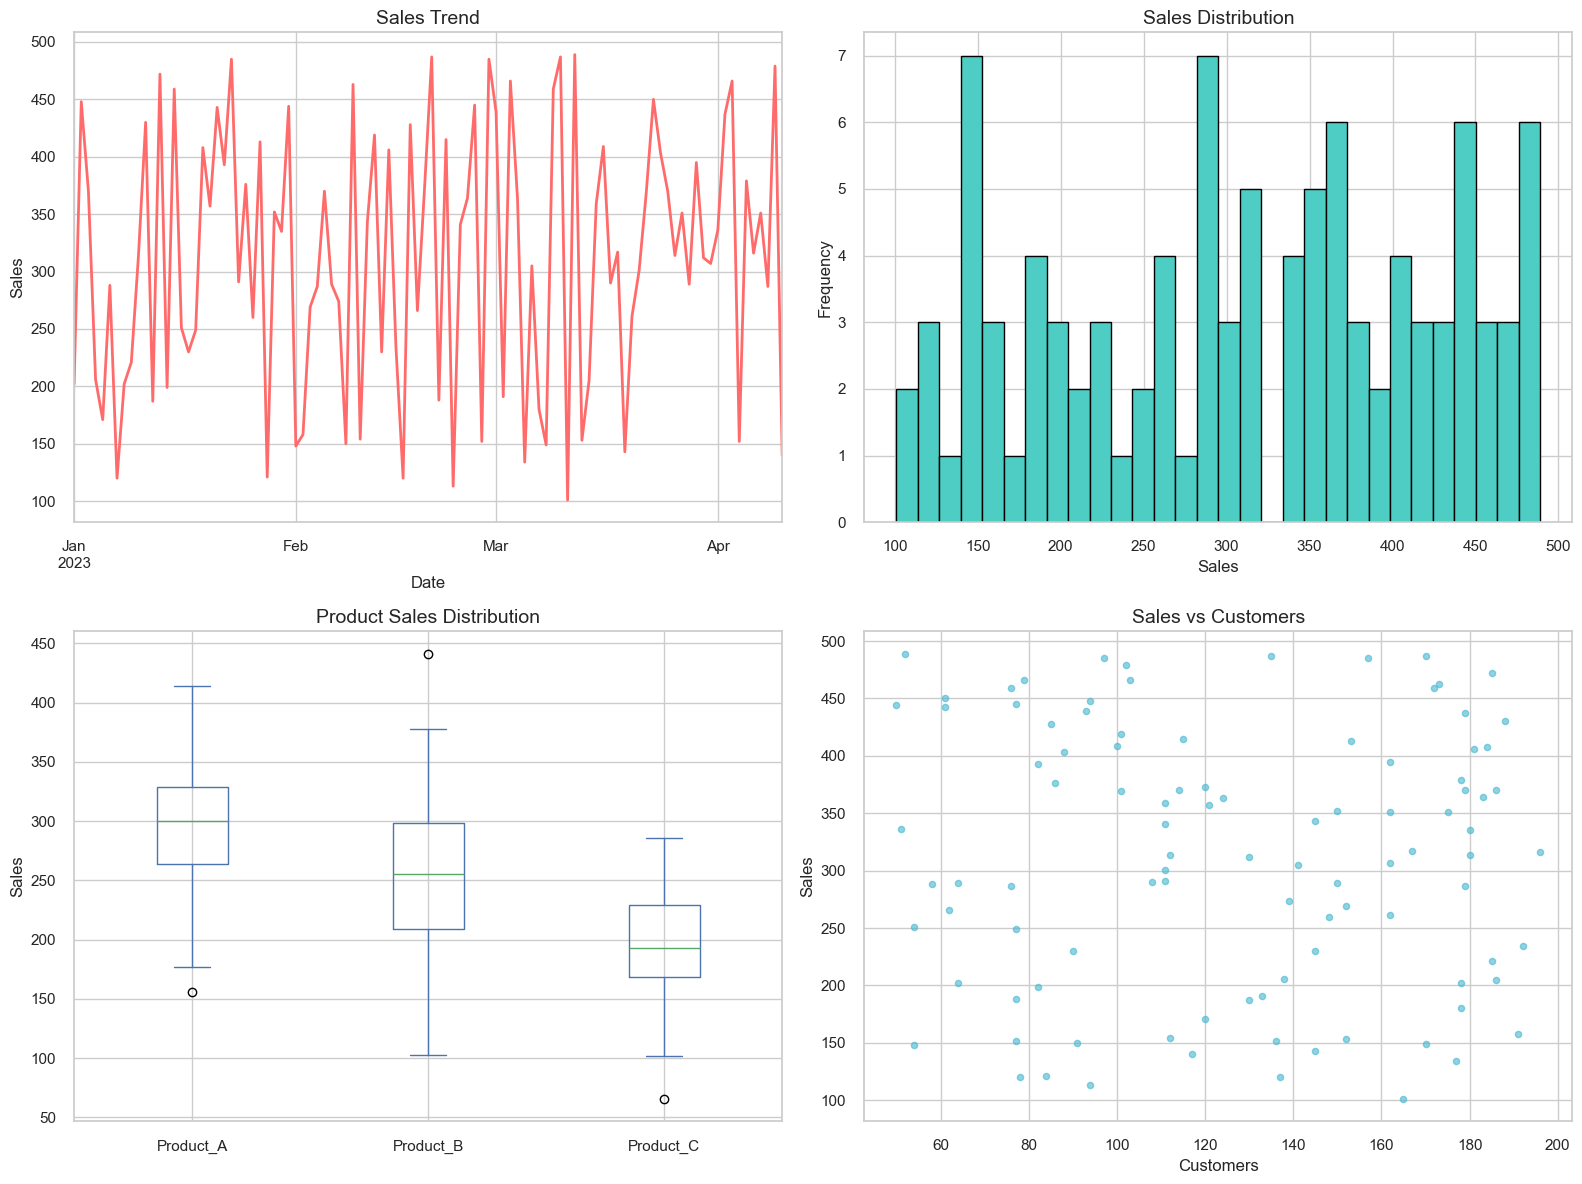

In [18]:
#Subplots - Multiple Visualizations
#Creating Multi-Plot Figures

# Create multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Line plot
df['Sales'].plot(ax=axes[0, 0], color='#FF6B6B', linewidth=2)
axes[0, 0].set_title('Sales Trend', fontsize=14)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Sales')

# 2. Histogram
df['Sales'].plot(ax=axes[0, 1], kind='hist', bins=30, color='#4ECDC4', edgecolor='black')
axes[0, 1].set_title('Sales Distribution', fontsize=14)
axes[0, 1].set_xlabel('Sales')
axes[0, 1].set_ylabel('Frequency')

# 3. Box plot
df[['Product_A', 'Product_B', 'Product_C']].plot(ax=axes[1, 0], kind='box')
axes[1, 0].set_title('Product Sales Distribution', fontsize=14)
axes[1, 0].set_ylabel('Sales')

# 4. Scatter plot
df.plot(ax=axes[1, 1], kind='scatter', x='Customers', y='Sales', color='#45B7D1', alpha=0.6)
axes[1, 1].set_title('Sales vs Customers', fontsize=14)
axes[1, 1].set_xlabel('Customers')
axes[1, 1].set_ylabel('Sales')

plt.tight_layout()
plt.show()

In [19]:
#Density Plots (KDE)
#Smooth Distribution Visualization

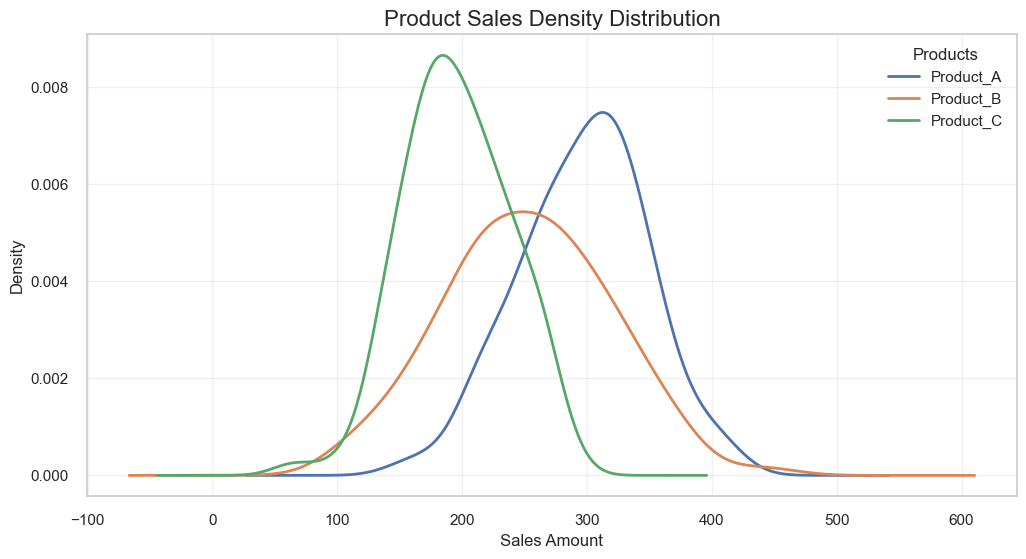

In [20]:
# Kernel Density Estimation plots
df[['Product_A', 'Product_B', 'Product_C']].plot(
    kind='kde',
    figsize=(12, 6),
    linewidth=2
)

plt.title('Product Sales Density Distribution', fontsize=16)
plt.xlabel('Sales Amount')
plt.ylabel('Density')
plt.legend(title='Products')
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
#Real-World Example - Sales Dashboard
#Complete Analysis Dashboard

In [ ]:
# dashboard with proper colorbar handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Ensure we're using the inline backend
%matplotlib inline

# Create sample data if not already loaded
np.random.seed(42)
dates = pd.date_range('2023-01-01', periods=100, freq='D')
df = pd.DataFrame({
    'Date': dates,
    'Sales': np.random.randint(100, 500, 100),
    'Customers': np.random.randint(50, 200, 100),
    'Product_A': np.random.normal(300, 50, 100),
    'Product_B': np.random.normal(250, 60, 100),
    'Product_C': np.random.normal(200, 40, 100)
})
df.set_index('Date', inplace=True)

# Create the dashboard
fig = plt.figure(figsize=(20, 15))

# Define grid layout
gs = GridSpec(3, 3, hspace=0.3, wspace=0.3, figure=fig)

# 1. Main sales trend (top row, span 3 columns)
ax1 = fig.add_subplot(gs[0, :])
df['Sales'].plot(ax=ax1, color='#2E86AB', linewidth=2, marker='o', markersize=3)
ax1.set_title('Daily Sales Trend - Full Period', fontsize=16, fontweight='bold')
ax1.set_ylabel('Sales ($)')
ax1.grid(True, alpha=0.3)

# 2. Monthly bar chart (middle row, first column)
ax2 = fig.add_subplot(gs[1, 0])
monthly_sales = df['Sales'].resample('M').sum()
monthly_sales.plot(ax=ax2, kind='bar', color='#4ECDC4')
ax2.set_title('Monthly Sales Total', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45)

# 3. Product distribution pie (middle row, second column)
ax3 = fig.add_subplot(gs[1, 1])
product_totals = df[['Product_A', 'Product_B', 'Product_C']].sum()
# Fix for pie chart - don't use plot, use ax.pie directly
wedges, texts, autotexts = ax3.pie(
    product_totals.values, 
    labels=product_totals.index,
    autopct='%1.1f%%',
    colors=['#FF6B6B', '#4ECDC4', '#45B7D1']
)
ax3.set_title('Product Sales Distribution', fontsize=12, fontweight='bold')

# 4. Sales histogram (middle row, third column)
ax4 = fig.add_subplot(gs[1, 2])
df['Sales'].plot(ax=ax4, kind='hist', bins=30, color='#45B7D1', edgecolor='black')
ax4.set_title('Sales Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Sales ($)')

# 5. Scatter plot (bottom row, span 2 columns) - FIXED VERSION
ax5 = fig.add_subplot(gs[2, :2])
# Use matplotlib scatter directly instead of pandas plot
scatter = ax5.scatter(
    x=df['Customers'],
    y=df['Sales'],
    c=df['Product_A'],
    cmap='viridis',
    s=50,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5
)
ax5.set_title('Sales vs Customers (colored by Product A)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Customers')
ax5.set_ylabel('Sales ($)')
ax5.grid(True, alpha=0.3)

# Add colorbar for scatter plot
cbar = plt.colorbar(scatter, ax=ax5, label='Product A Sales')
cbar.ax.yaxis.label.set_size(10)

# 6. Box plot (bottom row, last column)
ax6 = fig.add_subplot(gs[2, 2])
df[['Product_A', 'Product_B', 'Product_C']].plot(ax=ax6, kind='box')
ax6.set_title('Product Sales Distribution', fontsize=12, fontweight='bold')
ax6.set_ylabel('Sales ($)')
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45)
ax6.grid(True, alpha=0.3)

plt.suptitle('Sales Analytics Dashboard 2023', fontsize=20, fontweight='bold', y=0.98)
plt.show()